# Pure VQC with Amplitude Encoding — MNIST 4-class (digits 1, 3, 5, 7)

Follows arXiv 2301.12707:
- 8×8 images → 64 pixels → unit-norm normalised (eq. 2)
- `qml.StatePrep` encodes all 64 pixels as quantum amplitudes
- Custom Rx-Rz-Rx ansatz + nearest-neighbour CNOTs (paper Fig. 1 / eq. 3-5)
- Measure last 2 qubits → 4 outcomes → 4 classes
- `diff_method='backprop'` through `default.qubit` statevector — **zero noise, exact gradients**
- No parameter-shift overhead, no shots, no Qiskit Aer
- Adam optimizer via PennyLane TorchLayer

**Key improvement over original**: backprop through statevector gives noiseless, exact gradients.
The paper's high accuracy came from exact simulation — this matches that condition.

## 1 — Imports

In [50]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch import no_grad
from torch.utils.data import Dataset, DataLoader
from torch.nn import NLLLoss

from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_digits


import pennylane as qml

print('All imports OK')
print(f'PennyLane version: {qml.__version__}')

All imports OK
PennyLane version: 0.44.1


## 2 — Hyperparameters

In [51]:
N_QUBITS   = 6       # 2^6 = 64 — fits all 64 pixels as amplitudes exactly
N_TRAIN    = 350     # samples per class (400 total)
N_TEST     = 50      # samples per class (160 total)
N_LAYERS   = 7       # ansatz depth — increase toward 7 to approach paper accuracy
BATCH_SIZE = 1       # must be 1 for quantum simulation
LR         = 0.005
EPOCHS     = 10
LABELS     = [1, 3, 5, 7]
LABEL_MAP  = {1: 0, 3: 1, 5: 2, 7: 3}

## 3 — Data loading & preprocessing

Following equation (2) from the paper:
- Resize 28×28 → 8×8 (Nf = 64)
- Unit-norm normalise: **x** → **x**/||**x**||
- These 64 normalised values become the quantum amplitudes directly

In [54]:
from sklearn.datasets import load_digits
import numpy as np

digits = load_digits()

# Filter for digits 1, 3, 5, 7 only
mask = np.isin(digits.target, [1, 3, 5, 7])
X_raw = digits.data[mask]      # already 8x8 flattened to (N, 64), values 0-16
y_raw = digits.target[mask]

# Remap labels to 0,1,2,3
LABEL_MAP = {1: 0, 3: 1, 5: 2, 7: 3}
y_raw = np.array([LABEL_MAP[l] for l in y_raw])

# Unit-norm normalise — eq. (2)
norms = np.linalg.norm(X_raw, axis=1, keepdims=True)
X_raw = X_raw / (norms + 1e-10)

# Train/test split
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.32, random_state=42, stratify=y_raw
)
# test_size=0.32 gives roughly the paper's 1541 train / 726 test split

print(f'Train: {len(X_tr)}   Test: {len(X_te)}')
print(f'Norm check: {np.linalg.norm(X_tr[0]):.6f}')
print(f'X_tr: {X_tr.shape}')

Train: 493   Test: 233
Norm check: 1.000000
X_tr: (493, 64)


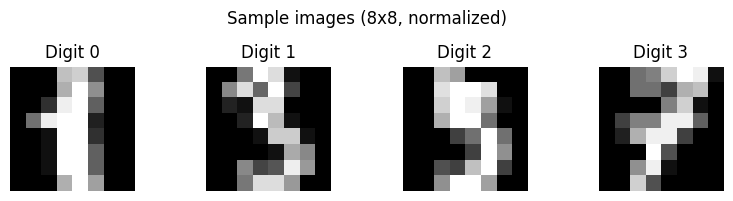

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(8, 2))

for i in range(4):
    # find first example of class i
    idx = np.where(y_raw == i)[0][0]

    # reshape 64 → 8x8
    img_8x8 = X_raw[idx].reshape(8, 8)

    axes[i].imshow(img_8x8, cmap='gray')
    axes[i].set_title(f'Digit {i}')  # or use original label if you want
    axes[i].axis('off')

plt.suptitle('Sample images (8x8, normalized)')
plt.tight_layout()
plt.show()

## 4 — DataLoaders

In [25]:
class VQCDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float64)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):         return len(self.X)
    def __getitem__(self, i):  return self.X[i], self.y[i]

# X_tr is (400, 64) — full pixel vectors, no PCA
train_loader = DataLoader(VQCDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(VQCDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}   Test batches: {len(test_loader)}')

Train batches: 493   Test batches: 233


## 5 — Quantum circuit (PennyLane)

Two parts:
- **Encoding**: `qml.StatePrep(pixel_values, wires=range(N_QUBITS))` loads all 64 pixel
  amplitudes into 6 qubits — directly equivalent to eq. (2) of the paper
- **Ansatz**: `Rx-Rz-Rx` per qubit + nearest-neighbour CNOTs repeated `N_LAYERS` times

`diff_method='backprop'` differentiates through the full statevector analytically.
No shots, no parameter-shift overhead, no noise — matches the paper's simulation exactly.

In [62]:
N_WEIGHTS = N_QUBITS * N_LAYERS * 3   # 3 rotation angles per qubit per layer

dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, diff_method='backprop', interface='torch')
def quantum_circuit(inputs, weights):
    """
    inputs  : shape (64,) — unit-norm pixel amplitudes
    weights : shape (N_WEIGHTS,) — trainable rotation angles
    returns : exact probability vector of length 4 over qubits [4, 5]
    """
    # Amplitude encoding — eq. (2) of the paper
    # StatePrep handles unit-norm validation internally
    qml.StatePrep(inputs, wires=range(N_QUBITS))

    # Ansatz — paper eq. (3-5): Rx-Rz-Rx per qubit + nearest-neighbour CNOTs
    p = 0
    for _ in range(N_LAYERS):
        for q in range(N_QUBITS):
            qml.RX(weights[p],     wires=q)
            qml.RZ(weights[p + 1], wires=q)
            qml.RX(weights[p + 2], wires=q)
            p += 3
        for q in range(N_QUBITS - 1):
            qml.CNOT(wires=[q, q + 1])

    # Last 2 qubits → 4 exact probabilities: |00>=class0, |01>=class1, |10>=class2, |11>=class3
    return qml.probs(wires=[4, 5])


print(f'Ansatz weight parameters: {N_WEIGHTS}')
print(f'Expected: {N_QUBITS} qubits x {N_LAYERS} layers x 3 = {N_QUBITS * N_LAYERS * 3}')


#Draw circuit with dummy inputs
dummy_pixels  = np.ones(64) / np.sqrt(64)
dummy_weights = np.zeros(N_WEIGHTS)
print('\nCircuit structure:')
print(qml.draw(quantum_circuit)(torch.tensor(dummy_pixels), torch.tensor(dummy_weights)))

Ansatz weight parameters: 126
Expected: 6 qubits x 7 layers x 3 = 126

Circuit structure:
0: ─╭|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╭●──RX(0.00)──RZ(0.00)──RX(0.00)───────────╭●─────── ···
1: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╰X─╭●─────────RX(0.00)──RZ(0.00)──RX(0.00)─╰X─────── ···
2: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)────╰X────────╭●─────────RX(0.00)──RZ(0.00)──RX(0.00) ···
3: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)──────────────╰X────────╭●─────────RX(0.00)──RZ(0.00) ···
4: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)────────────────────────╰X────────╭●─────────RX(0.00) ···
5: ─╰|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)──────────────────────────────────╰X─────────RX(0.00) ···

0: ··· ──RX(0.00)──RZ(0.00)──RX(0.00)───────────╭●─────────RX(0.00)──RZ(0.00)──RX(0.00) ···
1: ··· ─╭●─────────RX(0.00)──RZ(0.00)──RX(0.00)─╰X────────╭●─────────RX(0.00)──RZ(0.00) ···
2: ··· ─╰X────────╭●─────────RX(0.00)──RZ(0.00)──RX(0.00)─╰X────────╭●─────────RX(0.00) ···
3: ··· ──RX(0.00)─╰X────────╭●─────────RX(0.00)──RZ(0.00)

## 6 — Model

`AmplitudeVQC` wraps the QNode as a standard `nn.Module`.
The only trainable parameters are the ansatz rotation angles — the pixel amplitudes
are fed in as fixed inputs per sample, not as parameters.

In [27]:
LABELS = torch.tensor([1, 3, 5, 7], dtype=torch.long)


class AmplitudeVQC(nn.Module):
    """
    Pure VQC with amplitude encoding.
    The only trainable parameters are the ansatz rotation angles.
    Pixel values are embedded via qml.StatePrep per forward call.
    """
    def __init__(self, n_weights):
        super().__init__()
        # Initialise weights uniformly in [0, 2π] — same as paper
        self.weights = nn.Parameter(
            (torch.rand(n_weights) * 2 * torch.tensor(np.pi)).to(torch.float64)
        )

    def forward(self, x):
        # x: shape (1, 64) from DataLoader — squeeze to (64,) for StatePrep
        pixel_values = x.flatten().to(torch.float64)
        # Re-normalise defensively (already unit-norm from to_numpy, but be safe)
        pixel_values = pixel_values / pixel_values.norm()
        probs = quantum_circuit(pixel_values, self.weights)  # (4,) exact probabilities
        return probs.unsqueeze(0).to(torch.float32)          # (1, 4)


model = AmplitudeVQC(N_WEIGHTS)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters())}')

Trainable parameters: 126


## 7 — Training

In [28]:
optimizer = optim.Adam(model.parameters(), lr=LR)
loss_func = NLLLoss()

loss_history = []
model.train()

for epoch in range(1, EPOCHS + 1):
    batch_losses = []
    for x, y in train_loader:
        optimizer.zero_grad(set_to_none=True)

        probs  = model(x)                       # (1, 4) exact probabilities via backprop
        logits = torch.log(probs + 1e-10)       # log-probs for NLLLoss

        loss = loss_func(logits, y)
        loss.backward()                         # exact gradients through statevector
        optimizer.step()
        batch_losses.append(loss.item())

    avg_loss = float(np.mean(batch_losses))
    loss_history.append(avg_loss)
    print(f'Epoch {epoch:>2}/{EPOCHS}   loss: {avg_loss:.4f}')



Epoch  1/10   loss: 1.0421
Epoch  2/10   loss: 0.9075
Epoch  3/10   loss: 0.8850
Epoch  4/10   loss: 0.8733
Epoch  5/10   loss: 0.8567
Epoch  6/10   loss: 0.8446
Epoch  7/10   loss: 0.8351
Epoch  8/10   loss: 0.8320
Epoch  9/10   loss: 0.8230
Epoch 10/10   loss: 0.8160


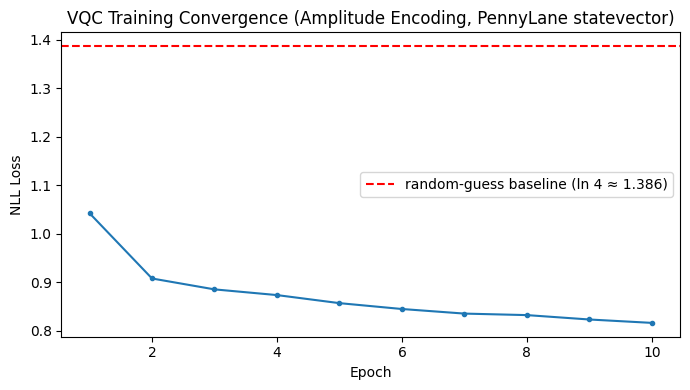

In [29]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', markersize=3)
plt.axhline(np.log(4), color='red', linestyle='--',
            label=f'random-guess baseline (ln 4 ≈ {np.log(4):.3f})')
plt.title('VQC Training Convergence (Amplitude Encoding, PennyLane statevector)')
plt.xlabel('Epoch')
plt.ylabel('NLL Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 8 — Evaluation

In [30]:
trained_weights = model.weights.detach().numpy()
np.save('trained_weights.npy', trained_weights)

model.eval()
correct     = 0
test_losses = []

with no_grad():
    for x, y in test_loader:
        probs  = model(x)                       # (1, 4)
        logits = torch.log(probs + 1e-10)
        pred   = probs.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        test_losses.append(loss_func(logits, y).item())

acc = correct / len(test_loader) * 100

model.eval()
correct_train = 0
with no_grad():
    for x, y in train_loader:
        probs = model(x)
        pred = probs.argmax(dim=1)
        correct_train += pred.eq(y).sum().item()
        
train_acc = correct_train / len(train_loader) * 100

print(f'Train accuracy : {train_acc:.1f}%')
print(f'Test accuracy  : {acc:.1f}%')
print(f'Test loss      : {np.mean(test_losses):.4f}')
print(f'Random baseline: 25.0%')


Train accuracy : 95.7%
Test accuracy  : 95.3%
Test loss      : 0.8238
Random baseline: 25.0%


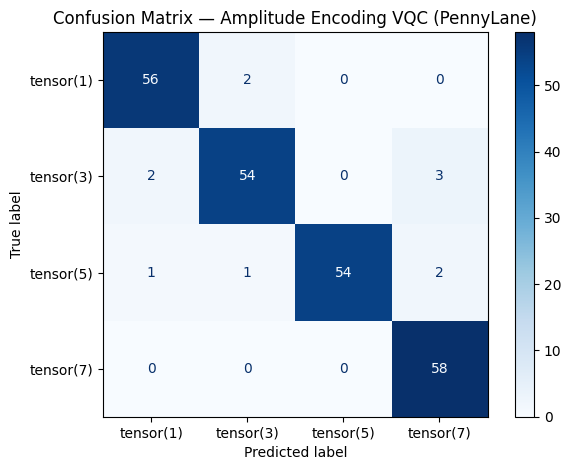

In [31]:
all_preds, all_targets = [], []
model.eval()
with no_grad():
    for x, y in test_loader:
        probs = model(x)
        all_preds.append(probs.argmax(dim=1).item())    
        all_targets.append(y.item())

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Amplitude Encoding VQC (PennyLane)')
plt.tight_layout()
plt.show()

## 9 — AdaBoost VQC (paper Section III.B)

Train `LC` weak VQCs sequentially. After each one, samples it got wrong
get higher weight in the next training round. Final prediction is a
weighted vote across all `LC` classifiers.

Paper equations implemented:
- Resampling   : indices drawn ∝ w_{l,i} each epoch (eq. 11 approximation)
- Error rate   : `e_l = Σ_i w_{l,i} · I(f_l(x_i) ≠ y_i)`  eq. (12)
- Classifier wt: `α_l = ln((1-e_l)/e_l) + ln(Kc-1)`        eq. (13)
- Weight update: `w_{l+1,i} = w_{l,i} · exp(α_l · wrong_i)` eq. (14)
- Final predict: weighted sum of all classifier probs         eq. (15)

In [36]:
import pennylane as qml
import torch
import numpy as np

n_qubits = 6
n_layers = 3   # make weak learners shallow

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qnode(x, weights):
    # Amplitude embedding
    qml.AmplitudeEmbedding(x, wires=range(n_qubits), normalize=True)

    # Variational layers
    p = 0
    for _ in range(n_layers):
        for q in range(n_qubits):
            qml.RX(weights[p], wires=q)
            qml.RZ(weights[p+1], wires=q)
            qml.RX(weights[p+2], wires=q)
            p += 3
        for q in range(n_qubits - 1):
            qml.CNOT(wires=[q, q+1])

    return qml.probs(wires=[4, 5])

class AmplitudeVQC(torch.nn.Module):
    def __init__(self, n_weights):
        super().__init__()
        self.weights = torch.nn.Parameter(
            0.01 * torch.randn(n_weights, dtype=torch.float64)
        )

    def forward(self, x):
        return qnode(x, self.weights)

def train_one_vqc(sample_weights):
    weak_model = AmplitudeVQC(n_qubits * n_layers * 3)
    optimizer = torch.optim.Adam(weak_model.parameters(), lr=0.01)

    X_all = torch.tensor(X_tr, dtype=torch.float64)
    y_all = torch.tensor(y_tr, dtype=torch.long)
    w_all = torch.tensor(sample_weights, dtype=torch.float64)

    weak_model.train()

    for epoch in range(ADA_EPOCHS):
        optimizer.zero_grad()

        total_loss = 0.0

        # 🔥 Weighted loss over FULL dataset (no resampling)
        for i in range(len(X_all)):
            x_i = X_all[i]
            y_i = y_all[i]
            w_i = w_all[i]

            probs = weak_model(x_i)

            # convert to log-prob safely
            log_probs = torch.log(probs + 1e-10)

            loss_i = torch.nn.functional.nll_loss(
                log_probs.unsqueeze(0),
                y_i.unsqueeze(0),
                reduction="none"
            )

            total_loss += w_i * loss_i

        total_loss.backward()
        optimizer.step()

        print(f"  Epoch {epoch+1}/{ADA_EPOCHS}  loss: {total_loss.item():.4f}")

    return weak_model

for l in range(LC):
    print(f'\n=== AdaBoost: weak classifier {l+1}/{LC} (3 layers) ===')
    print(f'  Weight range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]')

    weak_model = train_one_vqc(sample_weights)
    weak_models.append(weak_model)

    preds, _ = predict_train(weak_model)
    incorrect = (preds != y_tr).astype(float)
    e_l = float(np.dot(sample_weights, incorrect))

    if e_l >= (Kc - 1) / Kc:
        print(f'  Early stop: e_l={e_l:.4f} >= {(Kc-1)/Kc:.2f}, discarding.')
        weak_models.pop()
        break

    e_l     = np.clip(e_l, 1e-10, 1 - 1e-10)
    alpha_l = np.log((1 - e_l) / e_l) + np.log(Kc - 1)
    alphas.append(alpha_l)
    print(f'  e_l = {e_l:.4f}   alpha_l = {alpha_l:.4f}')

    sample_weights = sample_weights * np.exp(alpha_l * incorrect)
    sample_weights = sample_weights / sample_weights.sum()

    np.save(f'trained_ada_weights_{l}.npy', weak_model.weights.detach().numpy())

alphas = np.array(alphas)
print(f'\nClassifier weights alpha: {np.round(alphas, 3)}')
print(f'Saved {len(weak_models)} sets of AdaBoost weights (3-layer, {ADA_N_WEIGHTS} params each)')


=== AdaBoost: weak classifier 1/3 (3 layers) ===
  Weight range: [0.0020, 0.0020]
  Epoch 1/8  loss: 1.4480
  Epoch 2/8  loss: 1.4474
  Epoch 3/8  loss: 1.4455
  Epoch 4/8  loss: 1.4417
  Epoch 5/8  loss: 1.4361
  Epoch 6/8  loss: 1.4285
  Epoch 7/8  loss: 1.4192
  Epoch 8/8  loss: 1.4085
  e_l = 0.7485   alpha_l = 0.0081

=== AdaBoost: weak classifier 2/3 (3 layers) ===
  Weight range: [0.0020, 0.0020]
  Epoch 1/8  loss: 1.4484
  Epoch 2/8  loss: 1.4464
  Epoch 3/8  loss: 1.4429
  Epoch 4/8  loss: 1.4377
  Epoch 5/8  loss: 1.4311
  Epoch 6/8  loss: 1.4236
  Epoch 7/8  loss: 1.4157
  Epoch 8/8  loss: 1.4079
  Early stop: e_l=0.7593 >= 0.75, discarding.

Classifier weights alpha: [0.008]
Saved 1 sets of AdaBoost weights (3-layer, 54 params each)


In [ ]:
# ── AdaBoost uses its own 3-layer QNode — independent of main N_LAYERS ────────
ADA_N_LAYERS = 3
ADA_N_WEIGHTS = N_QUBITS * ADA_N_LAYERS * 3   # 54

dev_ada = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev_ada, diff_method='backprop', interface='torch')
def quantum_circuit_ada(inputs, weights):
    qml.StatePrep(inputs, wires=range(N_QUBITS))
    p = 0
    for _ in range(ADA_N_LAYERS):
        for q in range(N_QUBITS):
            qml.RX(weights[p],     wires=q)
            qml.RZ(weights[p + 1], wires=q)
            qml.RX(weights[p + 2], wires=q)
            p += 3
        for q in range(N_QUBITS - 1):
            qml.CNOT(wires=[q, q + 1])
    return qml.probs(wires=[4, 5])


class AdaAmplitudeVQC(nn.Module):
    """3-layer weak VQC for AdaBoost — separate from the main model."""
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            (torch.rand(ADA_N_WEIGHTS) * 2 * torch.tensor(np.pi)).to(torch.float64)
        )
    def forward(self, x):
        pv = x.flatten().to(torch.float64)
        pv = pv / pv.norm()
        return quantum_circuit_ada(pv, self.weights).unsqueeze(0).to(torch.float32)


print(f'AdaBoost QNode: {ADA_N_LAYERS} layers, {ADA_N_WEIGHTS} weights')
print(f'Main model    : {N_LAYERS} layers, {N_WEIGHTS} weights (unchanged)')

# ── AdaBoost hyperparameters ──────────────────────────────────────────────────
LC         = 3
ADA_LR     = 0.005
ADA_EPOCHS = 8
Kc         = 4

Ms = len(X_tr)
sample_weights = np.ones(Ms) / Ms

weak_models = []
alphas      = []


def predict_train(weak_model):
    weak_model.eval()
    all_preds, all_probs = [], []
    with no_grad():
        for i in range(len(X_tr)):
            x_i  = torch.tensor(X_tr[i], dtype=torch.float64).unsqueeze(0)
            probs = weak_model(x_i).squeeze(0).numpy()
            all_preds.append(np.argmax(probs))
            all_probs.append(probs)
    return np.array(all_preds), np.array(all_probs)


def train_one_vqc(sample_weights):
    weak_model = AdaAmplitudeVQC()   # 3-layer model
    weak_opt   = optim.Adam(weak_model.parameters(), lr=ADA_LR)
    weak_model.train()

    X_all    = torch.tensor(X_tr, dtype=torch.float64)
    y_all    = torch.tensor(y_tr, dtype=torch.long)
    w_tensor = torch.tensor(sample_weights, dtype=torch.float32)

    for epoch in range(ADA_EPOCHS):
        epoch_loss = 0.0
        perm = torch.multinomial(w_tensor, num_samples=len(X_all), replacement=True)
        for i in perm:
            x_i = X_all[i].unsqueeze(0)
            y_i = y_all[i].unsqueeze(0)
            weak_opt.zero_grad(set_to_none=True)
            probs  = weak_model(x_i)
            logits = torch.log(probs + 1e-10)
            loss   = torch.nn.functional.nll_loss(logits, y_i)
            loss.backward()
            weak_opt.step()
            epoch_loss += loss.item()
        print(f'  Epoch {epoch+1}/{ADA_EPOCHS}  loss: {epoch_loss/len(X_all):.4f}')

    return weak_model


# ── AdaBoost main loop ────────────────────────────────────────────────────────
for l in range(LC):
    print(f'\n=== AdaBoost: weak classifier {l+1}/{LC} (3 layers) ===')
    print(f'  Weight range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]')

    weak_model = train_one_vqc(sample_weights)
    weak_models.append(weak_model)

    preds, _ = predict_train(weak_model)
    incorrect = (preds != y_tr).astype(float)
    e_l = float(np.dot(sample_weights, incorrect))

    if e_l >= (Kc - 1) / Kc:
        print(f'  Early stop: e_l={e_l:.4f} >= {(Kc-1)/Kc:.2f}, discarding.')
        weak_models.pop()
        break

    e_l     = np.clip(e_l, 1e-10, 1 - 1e-10)
    alpha_l = np.log((1 - e_l) / e_l) + np.log(Kc - 1)
    alphas.append(alpha_l)
    print(f'  e_l = {e_l:.4f}   alpha_l = {alpha_l:.4f}')

    sample_weights = sample_weights * np.exp(alpha_l * incorrect)
    sample_weights = sample_weights / sample_weights.sum()

    np.save(f'trained_ada_weights_{l}.npy', weak_model.weights.detach().numpy())

alphas = np.array(alphas)
np.save("ada_alphas.npy", np.array(alphas))

print(f'\nClassifier weights alpha: {np.round(alphas, 3)}')
print(f'Saved {len(weak_models)} sets of AdaBoost weights (3-layer, {ADA_N_WEIGHTS} params each)')

AdaBoost QNode: 3 layers, 54 weights
Main model    : 7 layers, 126 weights (unchanged)

=== AdaBoost: weak classifier 1/3 (3 layers) ===
  Weight range: [0.0020, 0.0020]
  Epoch 1/8  loss: 1.1787
  Epoch 2/8  loss: 1.0676
  Epoch 3/8  loss: 1.0000
  Epoch 4/8  loss: 0.9338
  Epoch 5/8  loss: 0.9095
  Epoch 6/8  loss: 0.9354
  Epoch 7/8  loss: 0.9031
  Epoch 8/8  loss: 0.8957
  e_l = 0.0791   alpha_l = 3.5531

=== AdaBoost: weak classifier 2/3 (3 layers) ===
  Weight range: [0.0006, 0.0192]
  Epoch 1/8  loss: 1.1522
  Epoch 2/8  loss: 0.9526
  Epoch 3/8  loss: 0.8784
  Epoch 4/8  loss: 0.8861
  Epoch 5/8  loss: 0.8756
  Epoch 6/8  loss: 0.8907
  Epoch 7/8  loss: 0.8762
  Epoch 8/8  loss: 0.8880
  e_l = 0.2866   alpha_l = 2.0108

=== AdaBoost: weak classifier 3/3 (3 layers) ===
  Weight range: [0.0002, 0.0503]
  Epoch 1/8  loss: 1.2654
  Epoch 2/8  loss: 1.1354
  Epoch 3/8  loss: 1.0884
  Epoch 4/8  loss: 1.0636
  Epoch 5/8  loss: 1.0377
  Epoch 6/8  loss: 1.0567
  Epoch 7/8  loss: 1.007

In [48]:
# ── AdaBoost prediction on test set — eq. (15) ───────────────────────────────
def adaboost_predict(x_sample):
    """x_sample: numpy array shape (64,). Returns predicted class 0-3."""
    combined_probs = np.zeros(Kc)
    x_t = torch.tensor(x_sample, dtype=torch.float64).unsqueeze(0)
    for weak_model, alpha in zip(weak_models, alphas):
        weak_model.eval()
        with no_grad():
            probs = weak_model(x_t).squeeze(0).numpy()
        combined_probs += alpha * probs
    return int(np.argmax(combined_probs))


correct_ada = sum(
    adaboost_predict(X_te[i]) == y_te[i] for i in range(len(X_te))
)
ada_acc = correct_ada / len(X_te) * 100


print(f'\nAdaBoost test accuracy ({LC} classifiers): {ada_acc:.1f}%')
print(f'Single VQC test accuracy (from earlier):  {acc:.1f}%')
print(f'Improvement: {ada_acc - acc:+.1f}%')


AdaBoost test accuracy (3 classifiers): 94.8%
Single VQC test accuracy (from earlier):  95.3%
Improvement: -0.4%
